# Week 10 — Feature Attribution for Model Predictions
## S3_Tree Family: Decision Tree, Random Forest, Extra Trees

## Objective
- Explain WHY our Extra Trees model makes predictions
- Use SHAP TreeExplainer to find feature contributions
- Group features into 6 material groups
- Use Permutation Importance to validate SHAP results
- Compare both methods

In [2]:
# Install SHAP if not already installed
import subprocess
subprocess.run(["pip", "install", "shap"], capture_output=True)
print("SHAP ready")

SHAP ready


## Step 1: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from modeling import create_preprocessor, identify_column_types

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler

def create_preprocessor(numerical_cols, one_hot_columns, k_fold_columns, handle_unknown='ignore'):
    numerical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    preprocessor = ColumnTransformer([
        ('num', numerical_pipeline, numerical_cols),
        ('ohe', OneHotEncoder(handle_unknown=handle_unknown, sparse_output=False), one_hot_columns),
        ('target', TargetEncoder(cv=5, random_state=42), k_fold_columns)
    ])
    n_target = len(k_fold_columns)
    target_scaler = ColumnTransformer([
        ('scale_target', StandardScaler(), list(range(-n_target, 0)))
    ], remainder='passthrough')
    return Pipeline([
        ('preprocessor', preprocessor),
        ('scale_target_encoded', target_scaler)
    ])

print("All libraries loaded successfully")

All libraries loaded successfully


## Step 2: Load Dataset

We load the shared UHPC dataset with publication information.
Same dataset used in Week 8 and Week 9.

In [4]:
# Load shared dataset
df = pd.read_csv("semantic_recoding_features_50_with_publications.csv")

print("Dataset shape:", df.shape)
print("Target column: cs_28d")
print("Publications:", df['paper_reference'].nunique())
print("Target mean:", round(df['cs_28d'].mean(), 2), "MPa")

Dataset shape: (2073, 35)
Target column: cs_28d
Publications: 165
Target mean: 150.19 MPa


## Step 3: Separate Features and Target

- Target (y) = cs_28d (28-day compressive strength)
- Features (X) = all mix ingredients
- Keep publication ID for splitting

In [5]:
# Separate features, target, publication
X_raw = df.drop(columns=['cs_28d', 'paper_reference'])
y     = df['cs_28d']
pub   = df['paper_reference']

# Identify numeric and text columns
number_cols = X_raw.select_dtypes(include='number').columns.tolist()
text_cols = X_raw.select_dtypes(include=['object', 'str']).columns.tolist()

print("Features:        ", X_raw.shape[1])
print("Numeric columns: ", len(number_cols))
print("Text columns:    ", len(text_cols))
print("Text columns:    ", text_cols)

Features:         33
Numeric columns:  24
Text columns:     9
Text columns:     ['cement_type', 'fly_ash_type', 'slag_type', 'filler_type', 'sand_type', 'fiber1_type', 'fiber2_type', 'sp_type', 'curing_method']


## Step 4: Train / Validation / Test Split — 70/15/15

- Same split as Week 8 and Week 9
- GroupShuffleSplit keeps whole publications together
- Split happens BEFORE any preprocessing
- No data leakage

In [6]:
# Split off test 15%
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
trainval_idx, test_idx = next(gss1.split(X_raw, y, groups=pub))

X_trainval_raw = X_raw.iloc[trainval_idx].copy()
y_trainval     = y.iloc[trainval_idx]
pub_trainval   = pub.iloc[trainval_idx]
X_test_raw     = X_raw.iloc[test_idx].copy()
y_test         = y.iloc[test_idx]

# Split off validation 15%
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=42)
train_idx, val_idx = next(gss2.split(X_trainval_raw, y_trainval, groups=pub_trainval))

X_train_raw = X_trainval_raw.iloc[train_idx].copy()
y_train     = y_trainval.iloc[train_idx]
X_val_raw   = X_trainval_raw.iloc[val_idx].copy()
y_val       = y_trainval.iloc[val_idx]

print("Train size:      ", len(X_train_raw))
print("Validation size: ", len(X_val_raw))
print("Test size:       ", len(X_test_raw))

Train size:       1461
Validation size:  329
Test size:        283


## Step 5: Build Pipeline

- Pipeline handles all preprocessing automatically
- Numeric: SimpleImputer + StandardScaler
- OneHot: OneHotEncoder for low cardinality columns
- Target: TargetEncoder for high cardinality columns
- Fitted on train only — no leakage

In [7]:
# Identify column types
numerical_cols, one_hot_cols, target_cols = identify_column_types(X_train_raw)

print("Numeric columns: ", len(numerical_cols))
print("OneHot columns:  ", len(one_hot_cols))
print("Target columns:  ", len(target_cols))

# Build preprocessor
preprocessor = create_preprocessor(
    numerical_cols=numerical_cols,
    one_hot_columns=one_hot_cols,
    k_fold_columns=target_cols
)

# Build Extra Trees pipeline
et_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ExtraTreesRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_split=5,
        random_state=42
    ))
])

print("Pipeline created successfully!")

Numeric columns:  24
OneHot columns:   6
Target columns:   3
Pipeline created successfully!


## Step 6: Train Extra Trees Pipeline

- Train pipeline on training data
- Pipeline handles preprocessing automatically
- Evaluate on test set
- Frozen hyperparameters from Week 8

In [8]:
# Train pipeline on train data
et_pipeline.fit(X_train_raw, y_train)

# Evaluate on test set
et_test_pred = et_pipeline.predict(X_test_raw)
et_r2   = r2_score(y_test, et_test_pred)
et_rmse = np.sqrt(mean_squared_error(y_test, et_test_pred))

print("Extra Trees — Test Results")
print(f"R2:   {et_r2:.4f}")
print(f"RMSE: {et_rmse:.2f} MPa")

Extra Trees — Test Results
R2:   0.4833
RMSE: 21.58 MPa


## Step 7: SHAP TreeExplainer

- TreeExplainer is designed specifically for tree models
- We calculate SHAP values on the test set
- SHAP tells us how much each feature pushed prediction up or down

In [9]:
# Extract trained model from pipeline
et_model = et_pipeline.named_steps['model']

# Transform test data using pipeline preprocessor
X_test_transformed = et_pipeline[:-1].transform(X_test_raw)

# SHAP TreeExplainer
explainer = shap.TreeExplainer(et_model)

# Calculate SHAP values on transformed test set
shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values shape:", shap_values.shape)
print("Test set shape:   ", X_test_transformed.shape)
print("SHAP ready!")

SHAP values shape: (283, 69)
Test set shape:    (283, 69)
SHAP ready!


## Step 8: Feature Level SHAP

- Mean absolute SHAP value for each feature
- Higher value = more important feature
- Shows which individual ingredients matter most

Top 15 Most Important Features:
 1. cement_type                         5.9911
 2. curing_temp                         5.9344
 3. sand_type                           4.0486
 4. fiber1_amount                       3.3926
 5. water                               3.2566
 6. glass_powder                        3.2365
 7. fiber1_type_Straight Steel Fiber    3.1511
 8. curing_method_Standard Curing       2.6712
 9. fiber1_diameter                     1.7475
10. sp_type_PCE_HRWRA                   1.7014
11. silica_fume                         1.5325
12. cement                              1.3734
13. curing_method_Heat Curing           1.1732
14. quartz_powder                       1.0678
15. slag_type_Copper Slag               1.0040


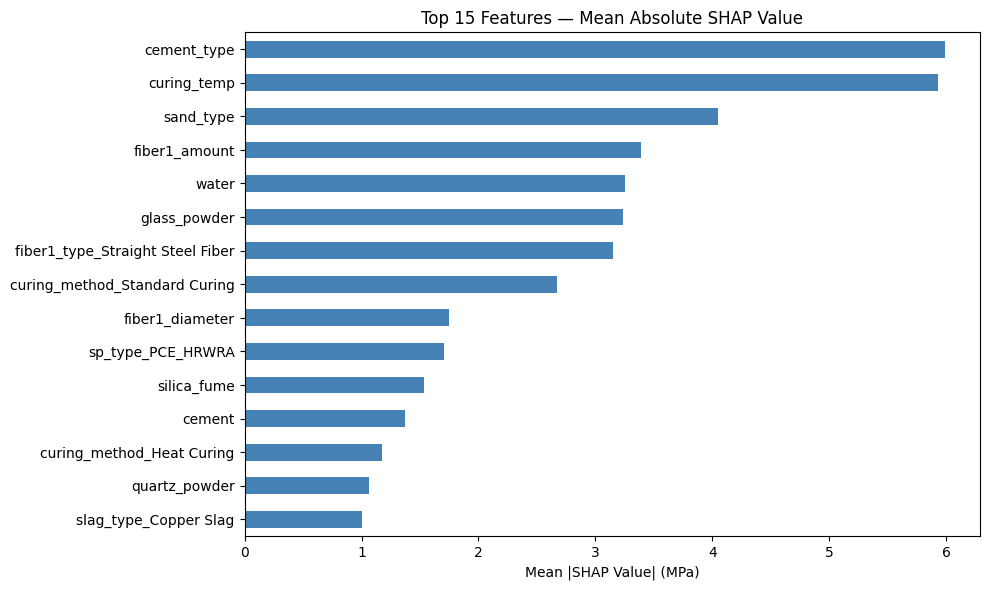

Chart saved!


In [10]:
# Get clean feature names
feature_names = et_pipeline[:-1].get_feature_names_out()

# Clean feature names — remove prefixes
def clean_name(name):
    name = name.replace('remainder__num__', '')
    name = name.replace('remainder__ohe__', '')
    name = name.replace('scale_target__target__', '')
    return name

feature_names_clean = [clean_name(n) for n in feature_names]

# Calculate mean absolute SHAP per feature
shap_mean = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_names_clean
).sort_values(ascending=False)

# Show top 15 features
print("Top 15 Most Important Features:")
print("="*45)
for i, (feat, val) in enumerate(shap_mean.head(15).items()):
    print(f"{i+1:2d}. {feat:<35} {val:.4f}")

# Bar chart
plt.figure(figsize=(10, 6))
shap_mean.head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Features — Mean Absolute SHAP Value')
plt.xlabel('Mean |SHAP Value| (MPa)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=150)
plt.show()
print("Chart saved!")

## Step 9: Map Transformed SHAP Columns Back to Original Features

Preprocessing expanded our 33 original features into 69 transformed columns.
We sum the SHAP values of every transformed column back into its original
feature using exact column name matching, not loose string search.

In [11]:
et_model = et_pipeline.named_steps['model']
X_test_transformed = et_pipeline[:-1].transform(X_test_raw)
transformed_names = et_pipeline[:-1].get_feature_names_out()

explainer = shap.TreeExplainer(et_model)
shap_values = explainer.shap_values(X_test_transformed)

def clean_name(name):
    for prefix in ['scale_target__target__', 'remainder__num__', 'remainder__ohe__']:
        name = name.replace(prefix, '')
    return name

clean_names = [clean_name(n) for n in transformed_names]

raw_features = X_test_raw.columns.tolist()
sorted_raw = sorted(raw_features, key=len, reverse=True)

shap_by_raw = pd.DataFrame(0.0, index=range(len(X_test_raw)), columns=raw_features)
for col_idx, cn in enumerate(clean_names):
    for rn in sorted_raw:
        if cn.startswith(rn):
            shap_by_raw[rn] += shap_values[:, col_idx]
            break

feature_shap_importance = shap_by_raw.abs().mean().sort_values(ascending=False)
print(feature_shap_importance.head(15))

cement_type        5.991099
curing_temp        5.934428
sand_type          4.048649
curing_method      3.897383
fiber1_type        3.427508
fiber1_amount      3.392567
water              3.256623
glass_powder       3.236486
sp_type            2.480953
fiber1_diameter    1.747498
silica_fume        1.532451
cement             1.373380
slag_type          1.357601
quartz_powder      1.067782
sand_max_size      0.640260
dtype: float64


### Step 9 (continued): Aggregate Original Features into Engineered Groups

- Map 33 original features into 6 engineered material groups
- Use exact column names for mapping
- Sum SHAP contributions of all features inside a group, per test row
- Take mean absolute value = total attribution magnitude of the group

In [12]:
feature_groups = {
    'Binders & SCMs': ['cement', 'cement_type', 'silica_fume', 'fly_ash', 'fly_ash_type',
                       'ggbfs', 'slag', 'slag_type', 'metakaolin', 'rice_husk_ash',
                       'quartz_powder', 'glass_powder', 'limestone_powder',
                       'nano_caco3', 'nano_al2o3', 'nano_tio2', 'nano_sio2'],
    'Fillers & Aggregates': ['sand', 'sand_type', 'sand_max_size', 'filler', 'filler_type'],
    'Fibers': ['fiber1_amount', 'fiber1_length', 'fiber1_diameter', 'fiber1_type',
               'fiber2_amount', 'fiber2_type'],
    'Curing Conditions': ['curing_temp', 'curing_method'],
    'Water': ['water'],
    'Chemical Admixtures': ['sp_amount', 'sp_type']
}

raw_to_group = {}
for g_name, f_list in feature_groups.items():
    for col in f_list:
        if col in raw_features:
            raw_to_group[col] = g_name

unassigned = [c for c in raw_features if c not in raw_to_group]
print("Unassigned features:", unassigned)

shap_by_group = pd.DataFrame(0.0, index=range(len(X_test_raw)), columns=list(feature_groups.keys()))
for rn in raw_features:
    shap_by_group[raw_to_group[rn]] += shap_by_raw[rn]

group_shap_importance = shap_by_group.abs().mean().sort_values(ascending=False)
print(group_shap_importance)

Unassigned features: []
Curing Conditions       9.694205
Binders & SCMs          9.203041
Fibers                  7.873781
Fillers & Aggregates    4.468537
Water                   3.256623
Chemical Admixtures     2.394428
dtype: float64


## Step 10: Held-Out Permutation Importance

Shuffle one feature at a time on the test set. Predict again with the same
trained model. Measure how much the test RMSE increases. Repeat 10 times
per feature and track the mean and standard deviation.

In [13]:
baseline_pred = et_pipeline.predict(X_test_raw)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print(f"Baseline test RMSE: {baseline_rmse:.2f} MPa")

n_repeats = 10
rng = np.random.default_rng(42)

perm_means = {}
perm_stds = {}

for col in X_test_raw.columns:
    rmse_increases = []
    for i in range(n_repeats):
        X_permuted = X_test_raw.copy()
        X_permuted[col] = rng.permutation(X_permuted[col].values)
        preds = et_pipeline.predict(X_permuted)
        rmse_new = np.sqrt(mean_squared_error(y_test, preds))
        rmse_increases.append(rmse_new - baseline_rmse)
    perm_means[col] = np.mean(rmse_increases)
    perm_stds[col] = np.std(rmse_increases)

perm_result = pd.Series(perm_means).sort_values(ascending=False)
print(perm_result.head(15))

Baseline test RMSE: 21.58 MPa
cement_type        2.944274
curing_temp        2.056483
fiber1_amount      2.034062
sand_type          1.371233
curing_method      1.360773
water              0.842592
cement             0.759599
quartz_powder      0.702503
silica_fume        0.391398
fiber1_type        0.343027
fiber1_diameter    0.207837
sp_type            0.191448
glass_powder       0.147931
sand               0.146866
sp_amount          0.098486
dtype: float64


## Step 11: Held-Out Group Permutation Importance

- Shuffle all features in one material group together
- Use the SAME row order for every column in that group
- Predict again and measure how much test RMSE increases
- This keeps correlated features inside a group linked together

In [14]:
feature_groups = {
    'Binders & SCMs': ['cement', 'cement_type', 'silica_fume', 'fly_ash', 'fly_ash_type',
                       'ggbfs', 'slag', 'slag_type', 'metakaolin', 'rice_husk_ash',
                       'quartz_powder', 'glass_powder', 'limestone_powder',
                       'nano_caco3', 'nano_al2o3', 'nano_tio2', 'nano_sio2'],
    'Fillers & Aggregates': ['sand', 'sand_type', 'sand_max_size', 'filler', 'filler_type'],
    'Fibers': ['fiber1_amount', 'fiber1_length', 'fiber1_diameter', 'fiber1_type',
               'fiber2_amount', 'fiber2_type'],
    'Curing Conditions': ['curing_temp', 'curing_method'],
    'Water': ['water'],
    'Chemical Admixtures': ['sp_amount', 'sp_type']
}

perm_group_means = {}
perm_group_stds = {}

for group_name, cols_in_group in feature_groups.items():
    cols = [c for c in cols_in_group if c in X_test_raw.columns]
    rmse_increases = []
    for i in range(n_repeats):
        X_permuted = X_test_raw.copy()
        shuffled_idx = rng.permutation(len(X_test_raw))
        for c in cols:
            X_permuted[c] = X_test_raw[c].values[shuffled_idx]
        preds = et_pipeline.predict(X_permuted)
        rmse_new = np.sqrt(mean_squared_error(y_test, preds))
        rmse_increases.append(rmse_new - baseline_rmse)
    perm_group_means[group_name] = np.mean(rmse_increases)
    perm_group_stds[group_name] = np.std(rmse_increases)

perm_group_result = pd.Series(perm_group_means).sort_values(ascending=False)
print(perm_group_result)

Curing Conditions       6.871937
Fibers                  4.061159
Binders & SCMs          3.875963
Fillers & Aggregates    1.490017
Water                   1.108301
Chemical Admixtures     0.286190
dtype: float64


## Step 12: Compare SHAP vs Permutation Rankings

- Compare top 10 features from SHAP and Permutation
- Count how many features appear in both lists
- Compare group-level rankings between both methods
- Identify which features are stable and which are contradictory

In [15]:
shap_top10 = set(feature_shap_importance.head(10).index)
perm_top10 = set(perm_result.head(10).index)
common = shap_top10 & perm_top10

print(f"Features in both Top 10: {len(common)}/10")
print("Common features:", sorted(common))

shap_group_rank = list(group_shap_importance.index)
perm_group_rank = list(perm_group_result.index)

print("\nGroup ranking — SHAP:       ", shap_group_rank)
print("Group ranking — Permutation:", perm_group_rank)

Features in both Top 10: 7/10
Common features: ['cement_type', 'curing_method', 'curing_temp', 'fiber1_amount', 'fiber1_type', 'sand_type', 'water']

Group ranking — SHAP:        ['Curing Conditions', 'Binders & SCMs', 'Fibers', 'Fillers & Aggregates', 'Water', 'Chemical Admixtures']
Group ranking — Permutation: ['Curing Conditions', 'Fibers', 'Binders & SCMs', 'Fillers & Aggregates', 'Water', 'Chemical Admixtures']


## Step 13: Final Summary — Week 10

Key findings from SHAP and Permutation Importance analysis.

In [16]:
print("WEEK 10 — FINAL SUMMARY")
print("="*50)
print()
print("Model: Extra Trees")
print(f"Test R2:   {et_r2:.4f}")
print(f"Test RMSE: {et_rmse:.2f} MPa")
print()
print("Top 5 Features by SHAP:")
for i, (feat, val) in enumerate(feature_shap_importance.head(5).items()):
    print(f"  {i+1}. {feat:<25} {val:.4f}")
print()
print("Group Level SHAP Ranking:")
for i, (group, val) in enumerate(group_shap_importance.items()):
    print(f"  {i+1}. {group:<24} {val:.4f}")
print()
print(f"SHAP vs Permutation Top-10 Agreement: {len(common)}/10")
print(f"Top group — SHAP: {shap_group_rank[0]}  |  Permutation: {perm_group_rank[0]}")

WEEK 10 — FINAL SUMMARY

Model: Extra Trees
Test R2:   0.4833
Test RMSE: 21.58 MPa

Top 5 Features by SHAP:
  1. cement_type               5.9911
  2. curing_temp               5.9344
  3. sand_type                 4.0486
  4. curing_method             3.8974
  5. fiber1_type               3.4275

Group Level SHAP Ranking:
  1. Curing Conditions        9.6942
  2. Binders & SCMs           9.2030
  3. Fibers                   7.8738
  4. Fillers & Aggregates     4.4685
  5. Water                    3.2566
  6. Chemical Admixtures      2.3944

SHAP vs Permutation Top-10 Agreement: 7/10
Top group — SHAP: Curing Conditions  |  Permutation: Curing Conditions


### Group-Level SHAP — Visual Summary

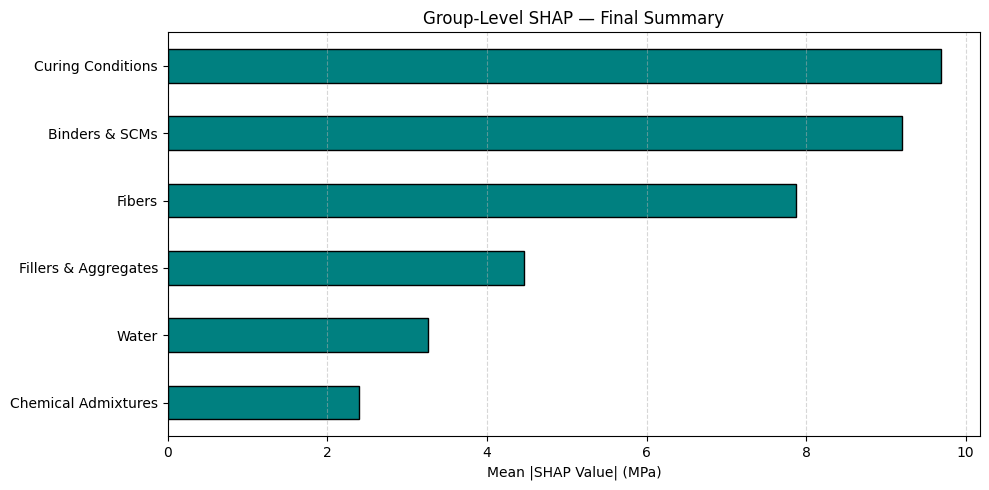

In [17]:
# Group-level SHAP bar chart
plt.figure(figsize=(10, 5))
group_shap_importance.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Group-Level SHAP — Final Summary')
plt.xlabel('Mean |SHAP Value| (MPa)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('shap_group_summary.png', dpi=150)
plt.show()


## Step 14: Worst Case Analysis — SHAP Waterfall Plot

Find the test prediction with the largest error. Use a SHAP waterfall plot
to show exactly which features pushed this specific prediction up or down,
and by how many MPa.

WORST CASE ANALYSIS
True Strength:      83.00 MPa
Model Predicted:    146.32 MPa
Prediction Error:   63.32 MPa


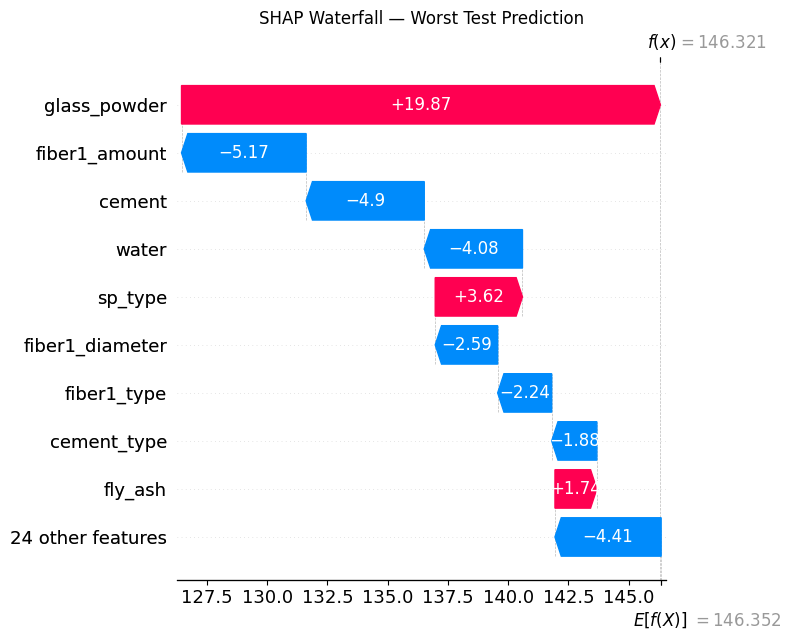

In [18]:
et_test_pred = et_pipeline.predict(X_test_raw)
errors = np.abs(y_test.values - et_test_pred)
worst_pos = int(np.argmax(errors))

print("WORST CASE ANALYSIS")
print(f"True Strength:      {y_test.values[worst_pos]:.2f} MPa")
print(f"Model Predicted:    {et_test_pred[worst_pos]:.2f} MPa")
print(f"Prediction Error:   {errors[worst_pos]:.2f} MPa")

worst_shap_raw = shap_by_raw.iloc[worst_pos]

base_value = explainer.expected_value
if isinstance(base_value, np.ndarray):
    base_value = float(base_value[0])

explanation = shap.Explanation(
    values=worst_shap_raw.values,
    base_values=base_value,
    feature_names=raw_features
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, max_display=10, show=False)
plt.title('SHAP Waterfall — Worst Test Prediction')
plt.tight_layout()
plt.savefig('shap_waterfall_worst_case.png', dpi=150, bbox_inches='tight')
plt.show()